In [30]:
%load_ext autoreload
%autoreload 2

In [31]:
import os
import sys
print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("../")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [64]:
from analysis import data_loading
from analysis.download_data import download_user_files

bucket_name = "human-dyna"
prefix = "data/"
#pattern = "data/data_user=*_name=r0-v2*debug=0.json"
human_data_pattern = "data/data_user=*exp4*v1*debug=0.json"
destination_folder = "/Users/wilka/git/research/results/human_dyna/user_data/exp4"

download_user_files(bucket_name, prefix, human_data_pattern, destination_folder)

Downloaded: data/data_user=1012357475_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json to /Users/wilka/git/research/results/human_dyna/user_data/exp4/data_user=1012357475_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json
Downloaded: data/data_user=1029753631_name=exp4-v1-r1-t0-paths_exp=4_debug=0.json to /Users/wilka/git/research/results/human_dyna/user_data/exp4/data_user=1029753631_name=exp4-v1-r1-t0-paths_exp=4_debug=0.json
Downloaded: data/data_user=1030545830_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json to /Users/wilka/git/research/results/human_dyna/user_data/exp4/data_user=1030545830_name=exp4-v1-r1-t0-shortcut_exp=4_debug=0.json
Downloaded: data/data_user=106628060_name=exp4-v1-r1-t0-start_exp=4_debug=0.json to /Users/wilka/git/research/results/human_dyna/user_data/exp4/data_user=106628060_name=exp4-v1-r1-t0-start_exp=4_debug=0.json
Downloaded: data/data_user=1093107832_name=exp4-v1-r0-t0-plan_exp=4_debug=0.json to /Users/wilka/git/research/results/human_dyna/user_data/exp4/data_u

In [62]:
from glob import glob
data_dir = '/Users/wilka/git/research/results/human_dyna/'
files = f'{data_dir}/user_data/*exp4*/*exp4*v1*.json'
user_base_path = f'{data_dir}/user_data'
files = list(set(glob(files)))
len(files)

165

In [118]:
# Define searches
searches = {
    'Paths': f'{data_dir}/user_data/*exp4*/*v1*paths*.json',
    'Start': f'{data_dir}/user_data/*exp4*/*v1*start*.json',
    'Plan (Tell)': f'{data_dir}/user_data/*exp4*/*v1*r1-t0-plan*.json',
    "Plan (Don't Tell)": f'{data_dir}/user_data/*exp4*/*v1*r0-t0-plan*.json',
    'Shortcut': f'{data_dir}/user_data/*exp4*/*v1*shortcut*.json',
}

valid_files = data_loading.get_valid_files(searches, plot=False)
len(valid_files)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Paths: 23/27 valid files
Start: 25/29 valid files
Plan (Tell): 24/38 valid files
Plan (Don't Tell): 24/35 valid files
Shortcut: 28/36 valid files


124

In [119]:
from pprint import pprint
import json
nfinished = 0
for idx, file in enumerate(valid_files):
    with open(file, 'r') as f:
        try:
            data = json.load(f)
        except Exception as e:
            print('-'*25)
            print(idx, os.path.basename(file))
            print(e)
            continue
        if not len(data): continue
        finished = data[-1].get("finished", False)
        if finished:
            print
            nfinished += 1
            print('-'*25)
            print(idx, os.path.basename(file))
            print("\n" + data[-1]['feedback'] or "N/A")
            print('bonus:', data[-1]['bonus'])
            print('feedback:')
            if 'feedback' in data[-2]['data']:
                pprint(data[-2]['data'])

        # else:
        #     print("NOT FINISHED")

-------------------------
0 data_user=1315907154_name=exp4-v1-r1-t0-paths_exp=4_debug=0.json

nice
bonus: 0
feedback:
-------------------------
1 data_user=1029753631_name=exp4-v1-r1-t0-paths_exp=4_debug=0.json


bonus: 0
feedback:
-------------------------
2 data_user=2420422968_name=exp4-v1-r1-t0-paths_exp=4_debug=0.json

No
bonus: 0
feedback:
-------------------------
3 data_user=2620963142_name=exp4-v1-r1-t0-paths_exp=4_debug=0.json

I didn't have any issues. Everything worked great.
bonus: 0
feedback:
-------------------------
4 data_user=4178566891_name=exp4-v1-r1-t0-paths_exp=4_debug=0.json

none
bonus: 0
feedback:
-------------------------
5 data_user=1669941346_name=exp4-v1-r1-t0-paths_exp=4_debug=0.json


bonus: 0
feedback:
-------------------------
6 data_user=1924282930_name=exp4-v1-r1-t0-paths_exp=4_debug=0.json


bonus: 0
feedback:
-------------------------
7 data_user=3439158218_name=exp4-v1-r1-t0-paths_exp=4_debug=0.json


bonus: 0
feedback:
-------------------------
8 

In [99]:
import json
# file = '/Users/wilka/git/research/results/human_dyna/user_data/exp4/data_user=1844620330_name=exp4-v1-r1-t0-plan_exp=4_debug=0.json'
file = '/Users/wilka/git/research/results/human_dyna//user_data/exp4/data_user=708665372_name=exp4-v1-r0-t0-plan_exp=4_debug=0.json'

with open(file, 'r') as f:
    data = json.load(f)

In [101]:
data[0]['data'].keys(), data[-2]['data'].keys()

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


(dict_keys(['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep']),
 dict_keys(['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep']))

In [77]:
import jax
from analysis import housemaze as housemaze_analysis
from housemaze import utils
from housemaze.human_dyna import multitask_env as maze
from housemaze.human_dyna import mazes
from experiment_utils import SuccessTrackingAutoResetWrapper

dummy_env_params = housemaze_analysis.get_params(mazes.big_practice_maze)
dummy_rng = jax.random.PRNGKey(42)
task_runner = maze.TaskRunner(task_objects=housemaze_analysis.task_objects)
base_env = maze.HouseMaze(
    task_runner=task_runner,
    num_categories=200,
)
web_env = SuccessTrackingAutoResetWrapper(base_env)
example_web_timestep = web_env.reset(dummy_rng, dummy_env_params)

# nenvs=25
# example_timestep = env.reset(dummy_rng, dummy_env_params)


In [94]:
# TESTING
df, data = data_loading.make_episode_data(file=file, example_timestep=example_web_timestep)
df.head()

Filtered 62 data points


maze,condition,name,block,manipulation,episode_idx,eval,task,room,user_id,age,sex,user,exp,debug,version,tell_reuse,timer,reversal
str,i64,str,str,i64,i64,bool,i64,i64,i64,i64,str,i64,i64,i64,i64,i64,i64,str
"""big_m4_maze_short_blind""",0,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,1,false,31,0,708665372,32,"""Male""",708665372,4,0,1,0,0,"""T,F"""
"""big_m4_maze_short_blind""",0,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,2,false,31,0,708665372,32,"""Male""",708665372,4,0,1,0,0,"""T,F"""
"""big_m4_maze_short_blind""",0,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,3,false,31,0,708665372,32,"""Male""",708665372,4,0,1,0,0,"""T,F"""
"""big_m4_maze_short_blind""",0,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,4,false,31,0,708665372,32,"""Male""",708665372,4,0,1,0,0,"""T,F"""
"""big_m4_maze_short_blind""",0,"""exp4-v1-r0-t0-plan""","""See if faster off train path t…",4,5,false,31,0,708665372,32,"""Male""",708665372,4,0,1,0,0,"""T,F"""


In [76]:
data_dicts = data

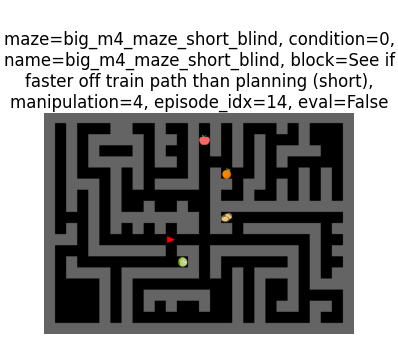

100
image: 2024-10-23T14:01:28.333Z
action time: 2024-10-23T14:01:28.701Z
action: 0


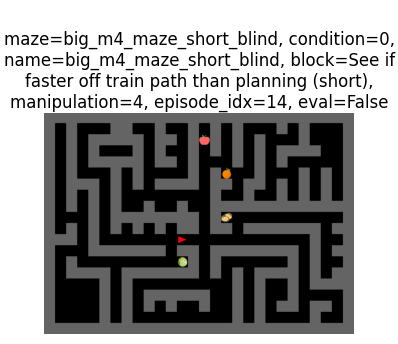

101
image: 2024-10-23T14:01:28.701Z
action time: 2024-10-23T14:01:29.372Z
action: 0


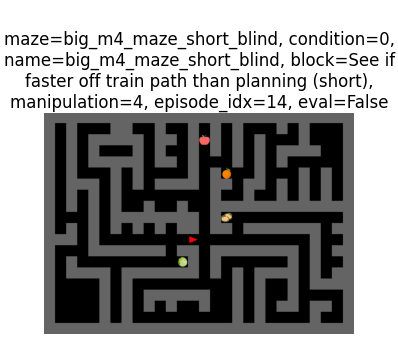

102
image: 2024-10-23T14:01:29.372Z
action time: 2024-10-23T14:01:30.093Z
action: 0


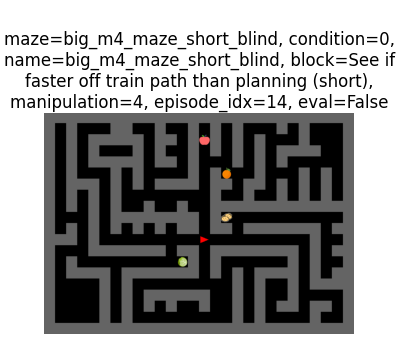

103
image: 2024-10-23T14:01:30.093Z
action time: 2024-10-23T14:01:31.310Z
action: 3


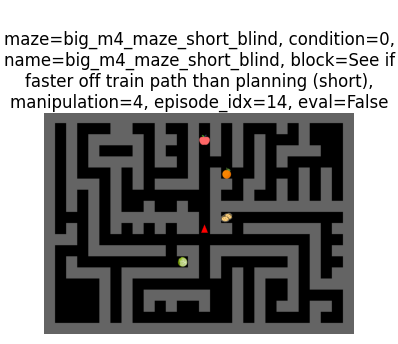

104
image: 2024-10-23T14:01:31.310Z
action time: 2024-10-23T14:01:31.816Z
action: 3


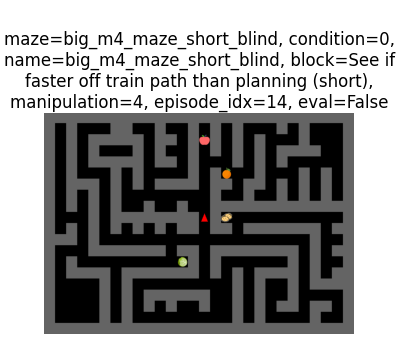

105
image: 2024-10-23T14:01:31.310Z
action time: 2024-10-23T14:01:31.846Z
action: 3


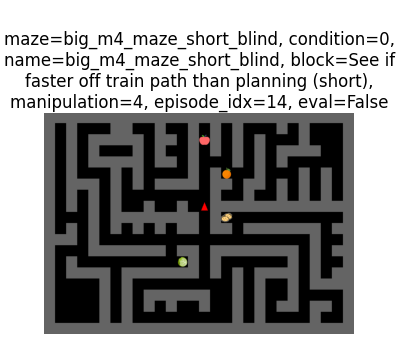

106
image: 2024-10-23T14:01:31.310Z
action time: 2024-10-23T14:01:31.877Z
action: 3


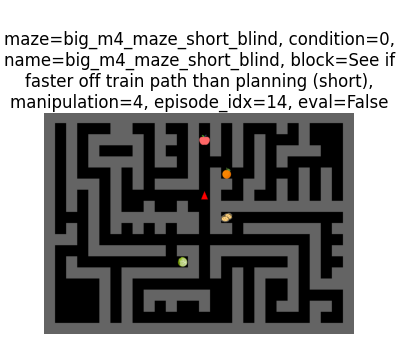

107
image: 2024-10-23T14:01:31.310Z
action time: 2024-10-23T14:01:31.907Z
action: 3


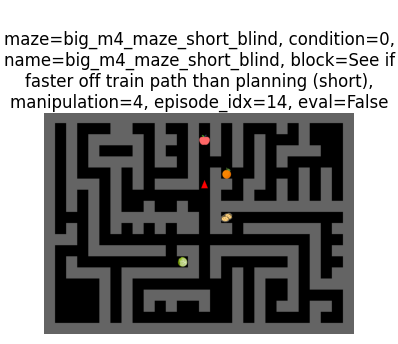

108
image: 2024-10-23T14:01:31.310Z
action time: 2024-10-23T14:01:31.948Z
action: 3


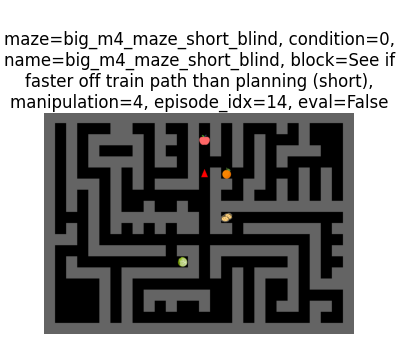

109
image: 2024-10-23T14:01:31.310Z
action time: 2024-10-23T14:01:31.976Z
action: 3


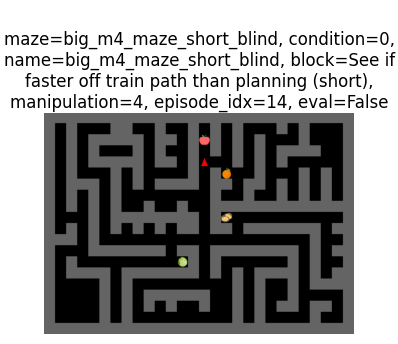

110
image: 2024-10-23T14:01:31.310Z
action time: 2024-10-23T14:01:32.007Z
action: 3


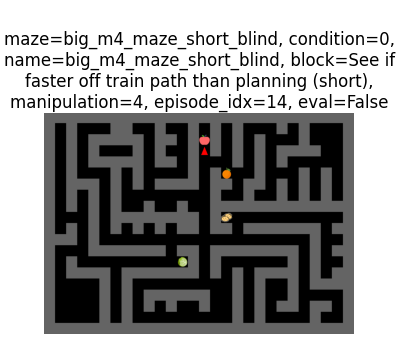

111
image: 2024-10-23T14:01:32.007Z
action time: 2024-10-23T14:01:32.047Z
action: 3


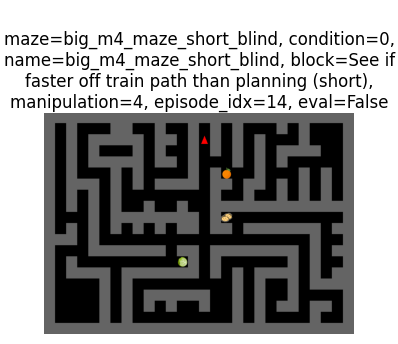

112
image: 2024-10-23T14:01:32.047Z
action time: 2024-10-23T14:01:32.079Z
action: 3


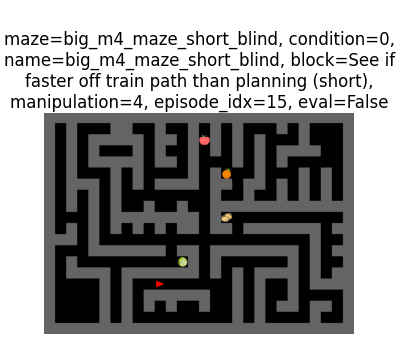

113
image: 2024-10-23T14:01:32.047Z
action time: 2024-10-23T14:01:32.107Z
action: 3


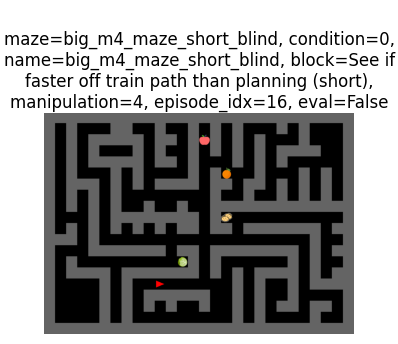

114
image: 2024-10-23T14:01:32.107Z
action time: 2024-10-23T14:01:32.146Z
action: 3


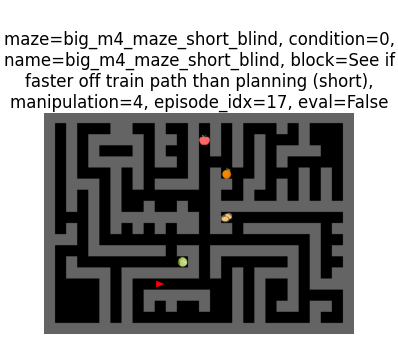

115
image: 2024-10-23T14:01:32.107Z
action time: 2024-10-23T14:01:32.178Z
action: 3


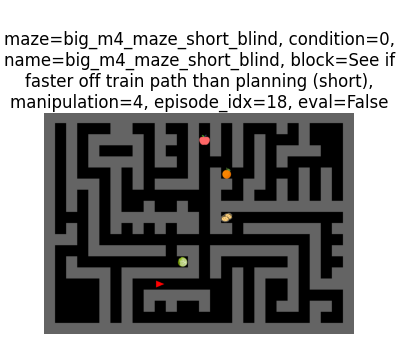

116
image: 2024-10-23T14:01:32.107Z
action time: 2024-10-23T14:01:32.207Z
action: 3


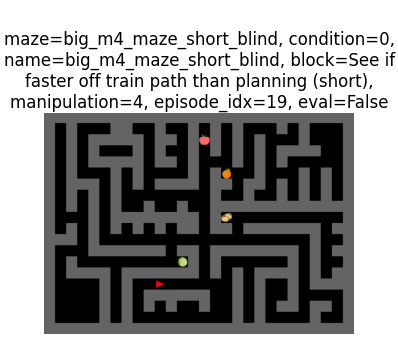

117
image: 2024-10-23T14:01:32.207Z
action time: 2024-10-23T14:01:32.240Z
action: 3


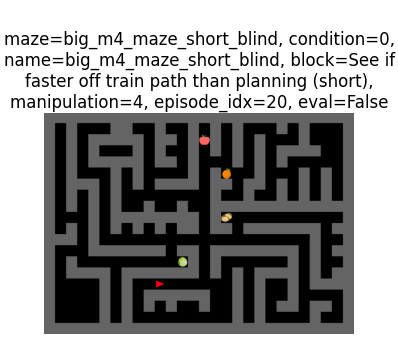

118
image: 2024-10-23T14:01:32.207Z
action time: 2024-10-23T14:01:32.279Z
action: 3


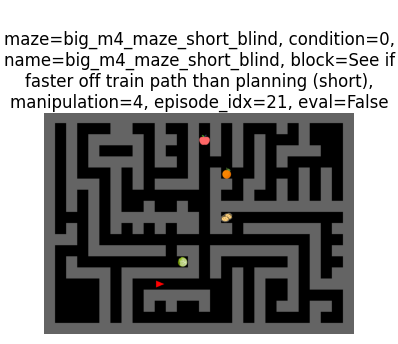

119
image: 2024-10-23T14:01:32.207Z
action time: 2024-10-23T14:01:32.308Z
action: 3


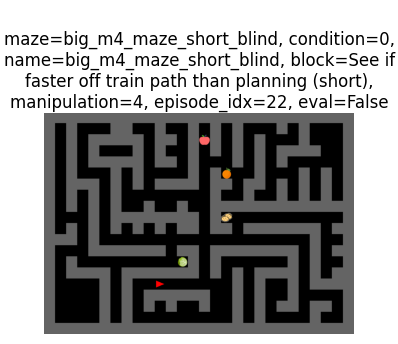

120
image: 2024-10-23T14:01:32.207Z
action time: 2024-10-23T14:01:32.339Z
action: 3


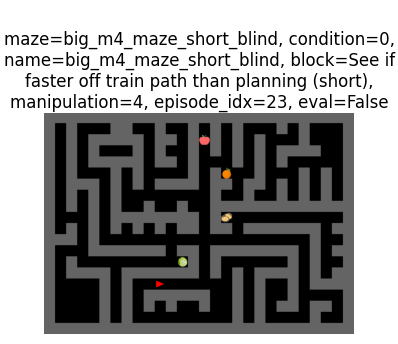

121
image: 2024-10-23T14:01:32.207Z
action time: 2024-10-23T14:01:32.379Z
action: 3


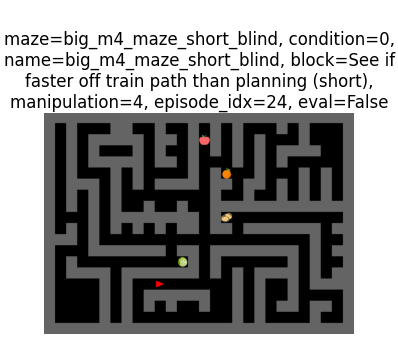

122
image: 2024-10-23T14:01:32.207Z
action time: 2024-10-23T14:01:32.408Z
action: 3


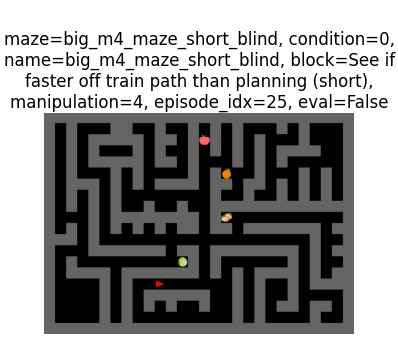

123
image: 2024-10-23T14:01:32.408Z
action time: 2024-10-23T14:01:32.445Z
action: 3


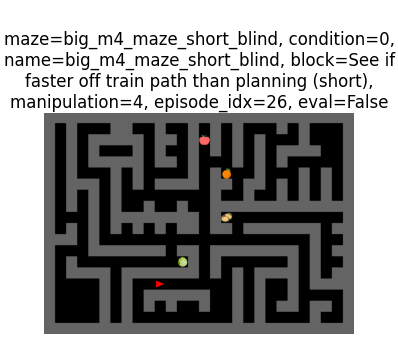

124
image: 2024-10-23T14:01:32.445Z
action time: 2024-10-23T14:01:32.480Z
action: 3


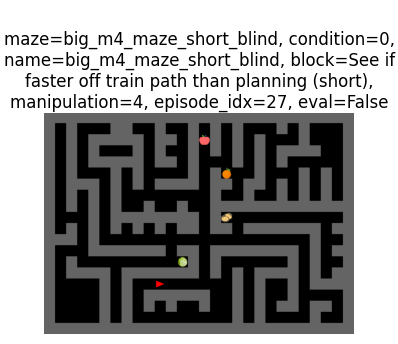

125
image: 2024-10-23T14:01:32.480Z
action time: 2024-10-23T14:01:32.511Z
action: 3


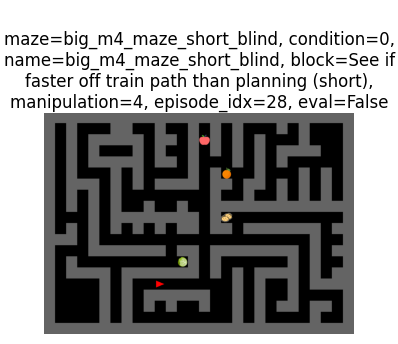

126
image: 2024-10-23T14:01:34.832Z
action time: 2024-10-23T14:01:36.444Z
action: 0


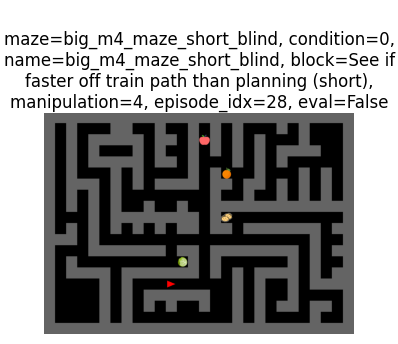

127
image: 2024-10-23T14:01:34.832Z
action time: 2024-10-23T14:01:36.628Z
action: 0


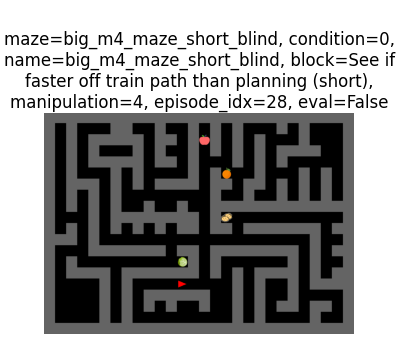

128
image: 2024-10-23T14:01:36.628Z
action time: 2024-10-23T14:01:36.803Z
action: 0


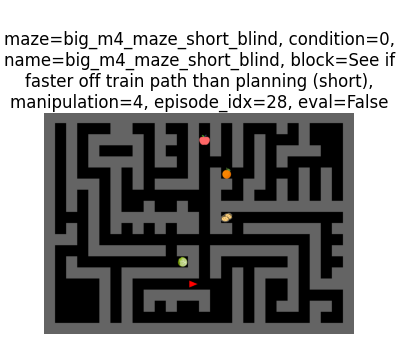

129
image: 2024-10-23T14:01:36.628Z
action time: 2024-10-23T14:01:36.956Z
action: 0


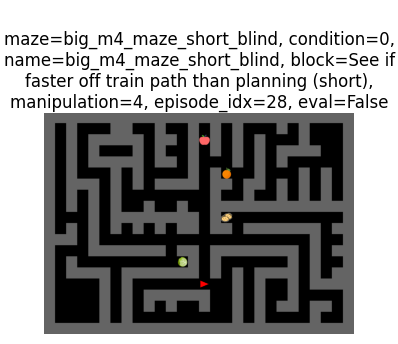

130
image: 2024-10-23T14:01:36.956Z
action time: 2024-10-23T14:01:37.131Z
action: 0


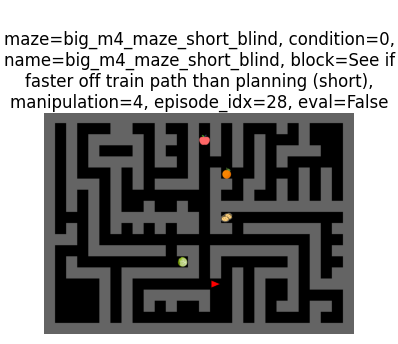

131
image: 2024-10-23T14:01:37.131Z
action time: 2024-10-23T14:01:37.812Z
action: 0


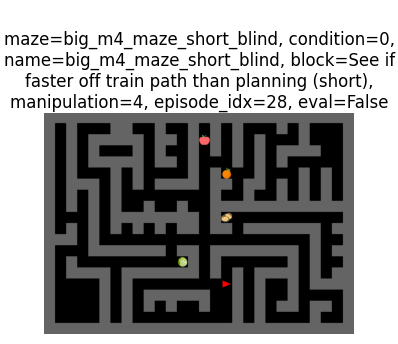

132
image: 2024-10-23T14:01:37.811Z
action time: 2024-10-23T14:01:39.043Z
action: 2


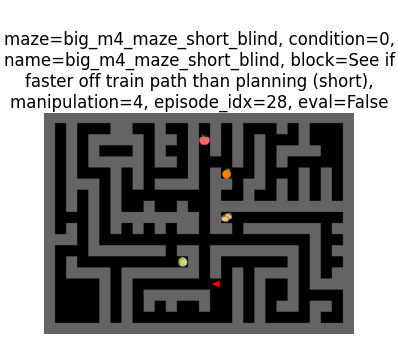

133
image: 2024-10-23T14:01:39.043Z
action time: 2024-10-23T14:01:39.788Z
action: 2


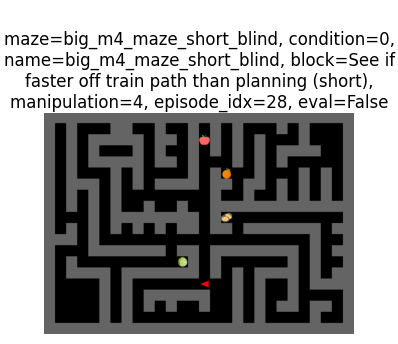

134
image: 2024-10-23T14:01:39.788Z
action time: 2024-10-23T14:01:40.364Z
action: 3


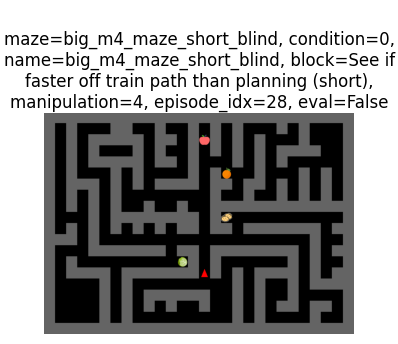

135
image: 2024-10-23T14:01:40.364Z
action time: 2024-10-23T14:01:40.861Z
action: 3


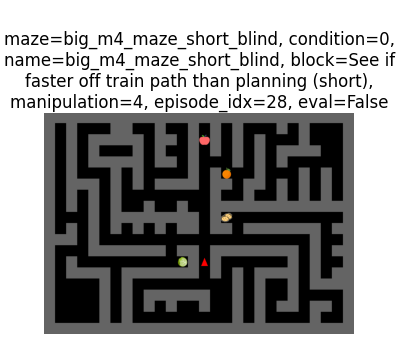

136
image: 2024-10-23T14:01:40.364Z
action time: 2024-10-23T14:01:40.899Z
action: 3


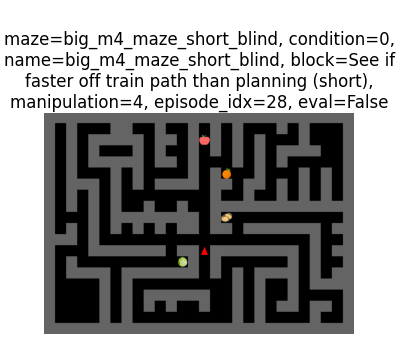

137
image: 2024-10-23T14:01:40.364Z
action time: 2024-10-23T14:01:40.930Z
action: 3


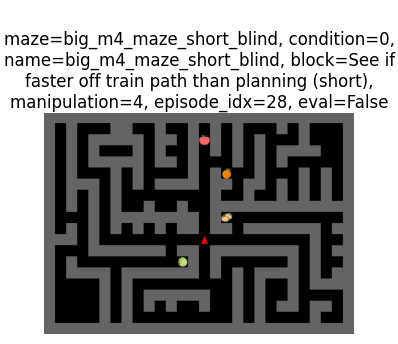

138
image: 2024-10-23T14:01:40.364Z
action time: 2024-10-23T14:01:40.963Z
action: 3


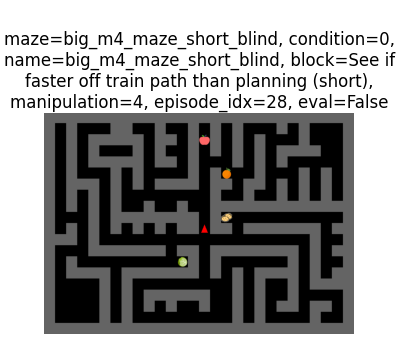

139
image: 2024-10-23T14:01:40.364Z
action time: 2024-10-23T14:01:41.000Z
action: 3


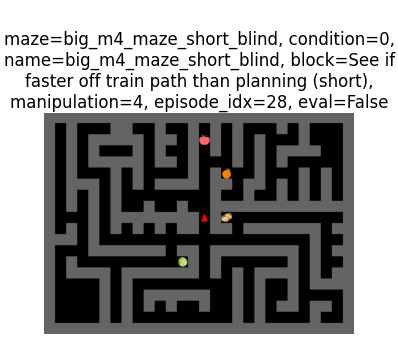

140
image: 2024-10-23T14:01:40.364Z
action time: 2024-10-23T14:01:41.030Z
action: 3


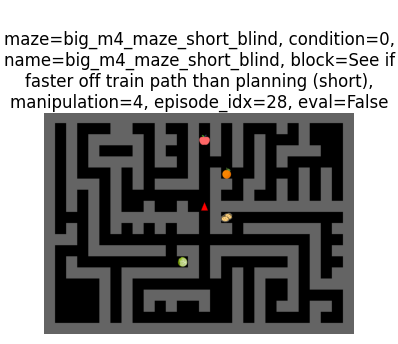

141
image: 2024-10-23T14:01:40.364Z
action time: 2024-10-23T14:01:41.061Z
action: 3


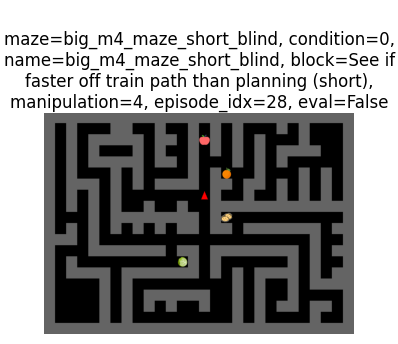

142
image: 2024-10-23T14:01:41.061Z
action time: 2024-10-23T14:01:41.090Z
action: 3


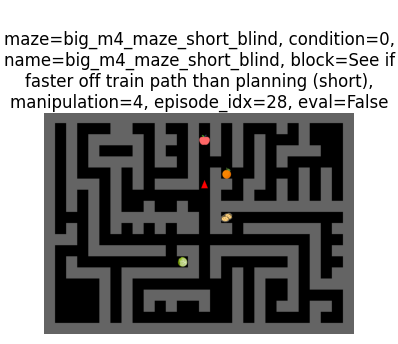

143
image: 2024-10-23T14:01:41.090Z
action time: 2024-10-23T14:01:41.132Z
action: 3


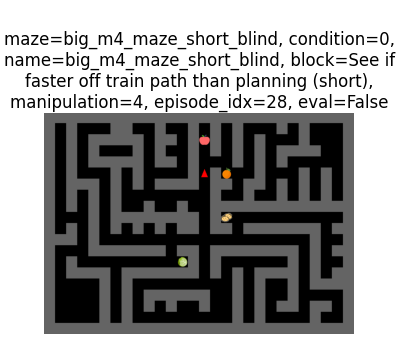

144
image: 2024-10-23T14:01:41.090Z
action time: 2024-10-23T14:01:41.161Z
action: 3


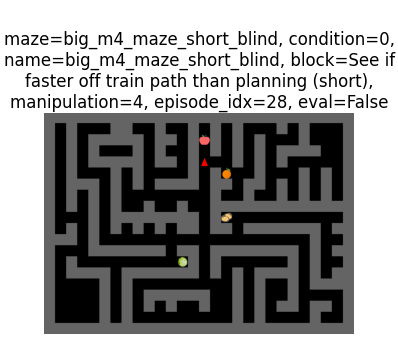

145
image: 2024-10-23T14:01:41.161Z
action time: 2024-10-23T14:01:41.196Z
action: 3


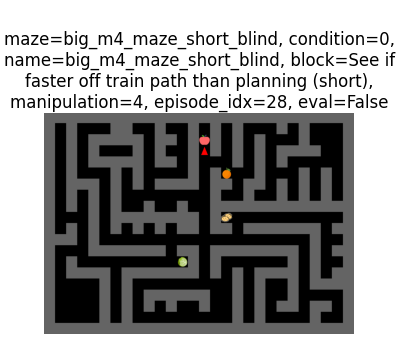

146
image: 2024-10-23T14:01:41.161Z
action time: 2024-10-23T14:01:41.232Z
action: 3


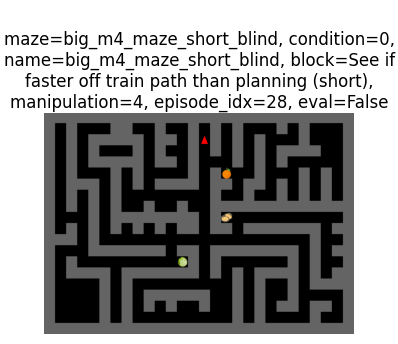

147
image: 2024-10-23T14:01:41.161Z
action time: 2024-10-23T14:01:41.261Z
action: 3


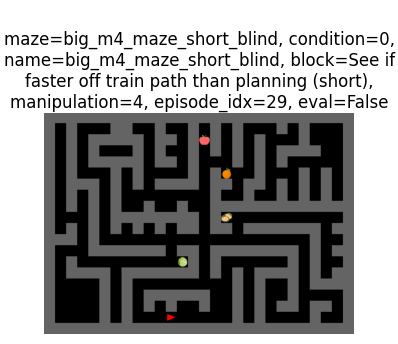

148
image: 2024-10-23T14:01:41.261Z
action time: 2024-10-23T14:01:41.291Z
action: 3


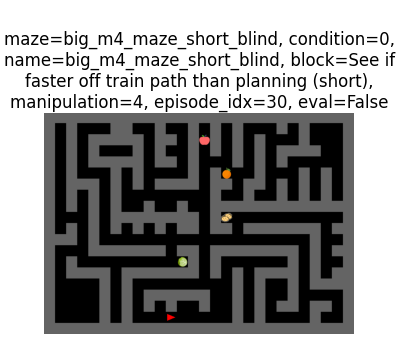

149
image: 2024-10-23T14:01:41.261Z
action time: 2024-10-23T14:01:41.330Z
action: 3


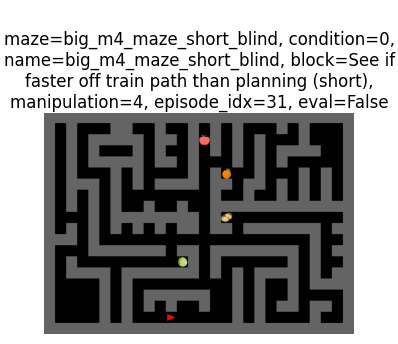

150
image: 2024-10-23T14:01:41.261Z
action time: 2024-10-23T14:01:41.360Z
action: 3


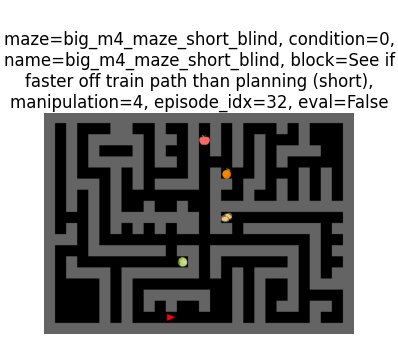

151
image: 2024-10-23T14:01:41.261Z
action time: 2024-10-23T14:01:41.390Z
action: 3


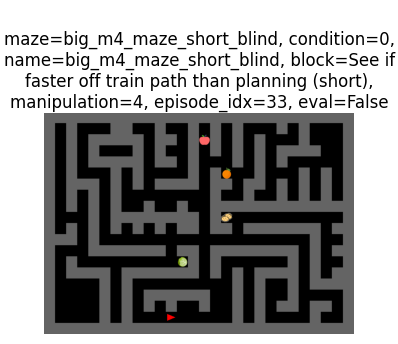

152
image: 2024-10-23T14:01:41.390Z
action time: 2024-10-23T14:01:41.420Z
action: 3


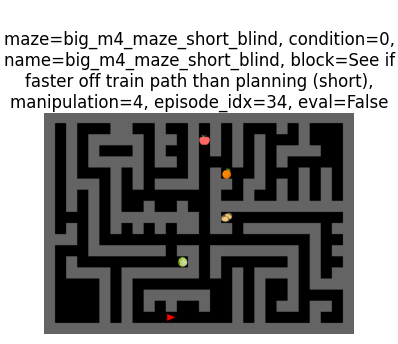

153
image: 2024-10-23T14:01:41.420Z
action time: 2024-10-23T14:01:41.460Z
action: 3


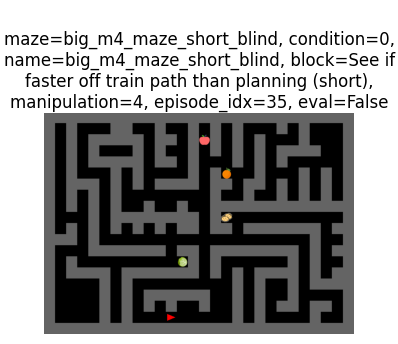

154
image: 2024-10-23T14:01:41.420Z
action time: 2024-10-23T14:01:41.493Z
action: 3


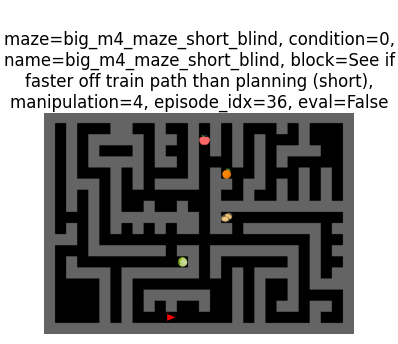

155
image: 2024-10-23T14:01:41.493Z
action time: 2024-10-23T14:01:41.519Z
action: 3


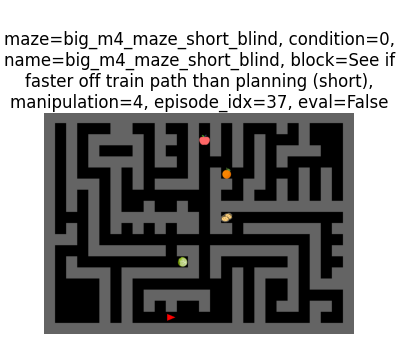

156
image: 2024-10-23T14:01:41.493Z
action time: 2024-10-23T14:01:41.560Z
action: 3


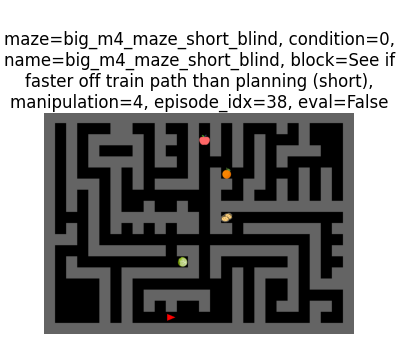

157
image: 2024-10-23T14:01:41.493Z
action time: 2024-10-23T14:01:41.589Z
action: 3


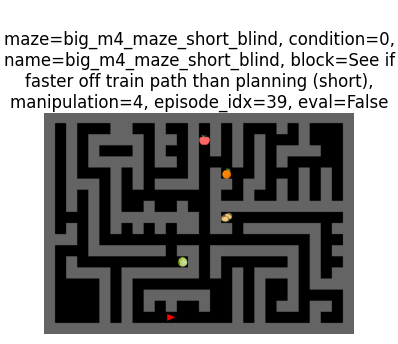

158
image: 2024-10-23T14:01:41.589Z
action time: 2024-10-23T14:01:41.620Z
action: 3


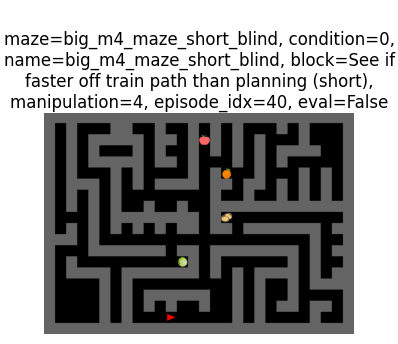

159
image: 2024-10-23T14:01:41.589Z
action time: 2024-10-23T14:01:41.660Z
action: 3


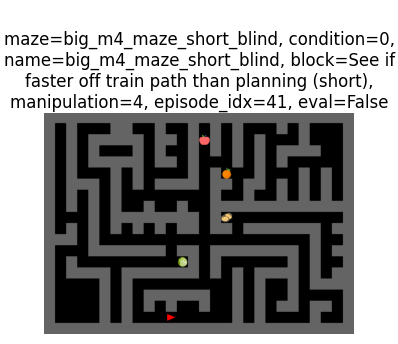

160
image: 2024-10-23T14:01:41.589Z
action time: 2024-10-23T14:01:41.689Z
action: 3


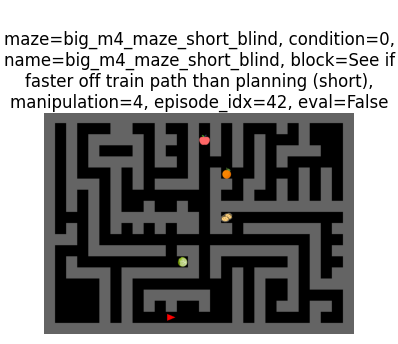

161
image: 2024-10-23T14:01:41.589Z
action time: 2024-10-23T14:01:41.721Z
action: 3


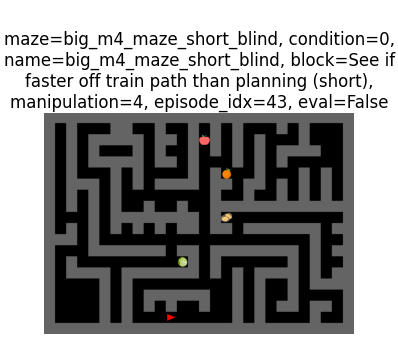

162
image: 2024-10-23T14:01:41.589Z
action time: 2024-10-23T14:01:41.750Z
action: 3


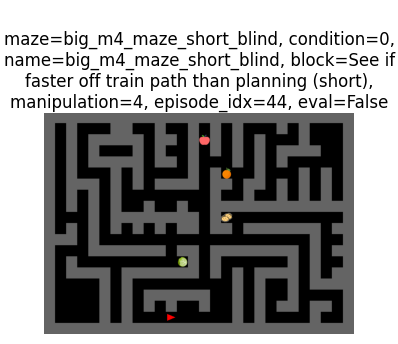

163
image: 2024-10-23T14:01:41.589Z
action time: 2024-10-23T14:01:41.790Z
action: 3


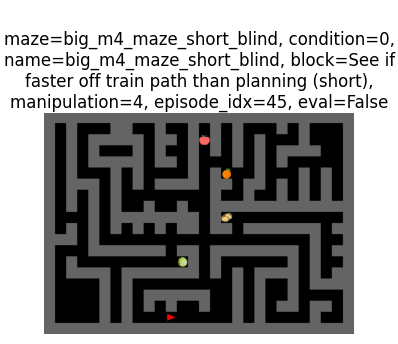

164
image: 2024-10-23T14:01:41.789Z
action time: 2024-10-23T14:01:41.820Z
action: 3


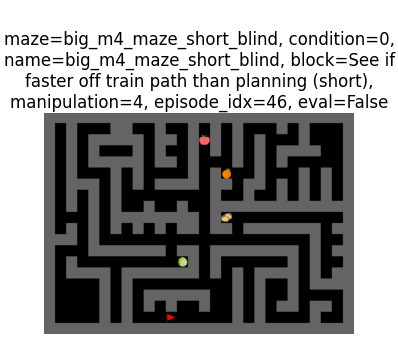

165
image: 2024-10-23T14:01:41.789Z
action time: 2024-10-23T14:01:41.849Z
action: 3


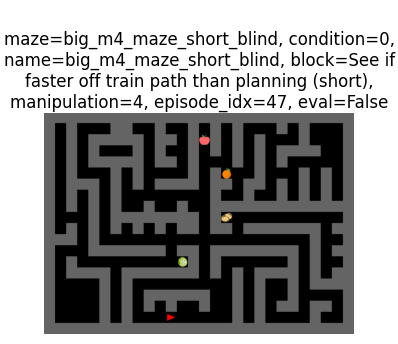

166
image: 2024-10-23T14:01:41.849Z
action time: 2024-10-23T14:01:41.890Z
action: 3


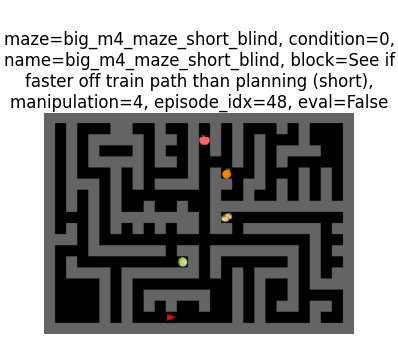

167
image: 2024-10-23T14:01:41.849Z
action time: 2024-10-23T14:01:41.921Z
action: 3


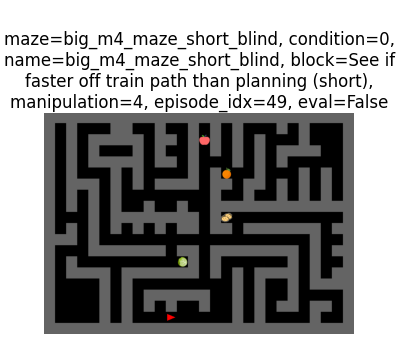

168
image: 2024-10-23T14:01:41.921Z
action time: 2024-10-23T14:01:41.956Z
action: 3


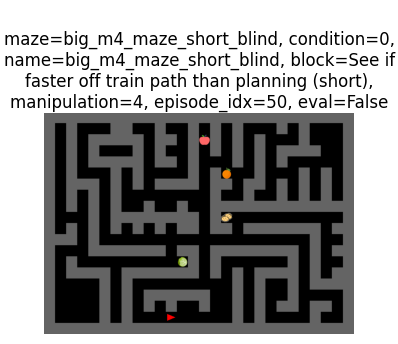

169
image: 2024-10-23T14:01:43.922Z
action time: 2024-10-23T14:01:53.210Z
action: 0


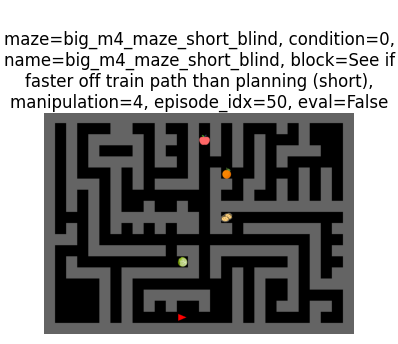

170
image: 2024-10-23T14:01:53.210Z
action time: 2024-10-23T14:01:53.730Z
action: 0


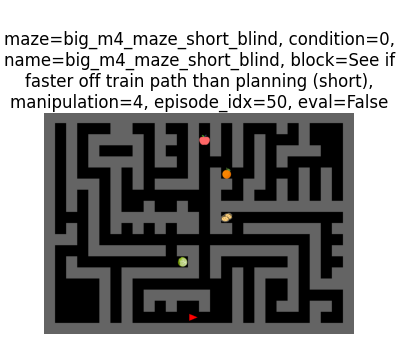

171
image: 2024-10-23T14:01:53.730Z
action time: 2024-10-23T14:01:54.114Z
action: 0


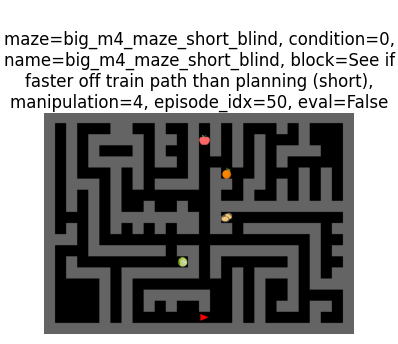

172
image: 2024-10-23T14:01:54.114Z
action time: 2024-10-23T14:01:54.809Z
action: 0


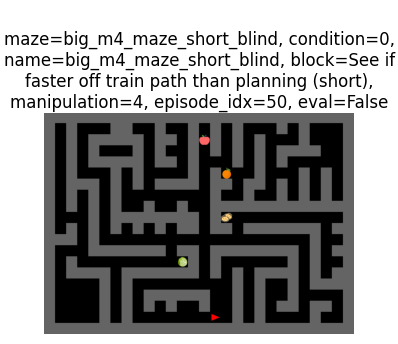

173
image: 2024-10-23T14:01:54.809Z
action time: 2024-10-23T14:01:55.493Z
action: 3


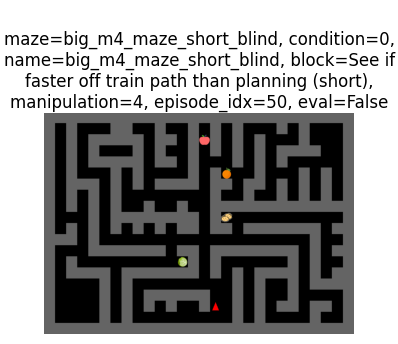

174
image: 2024-10-23T14:01:55.493Z
action time: 2024-10-23T14:01:56.163Z
action: 3


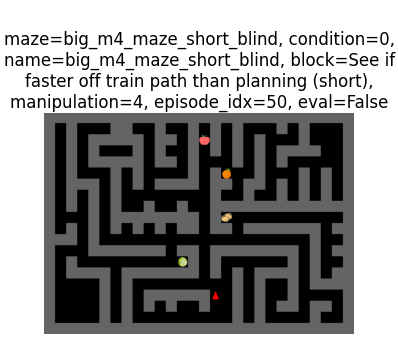

175
image: 2024-10-23T14:01:56.163Z
action time: 2024-10-23T14:01:56.921Z
action: 3


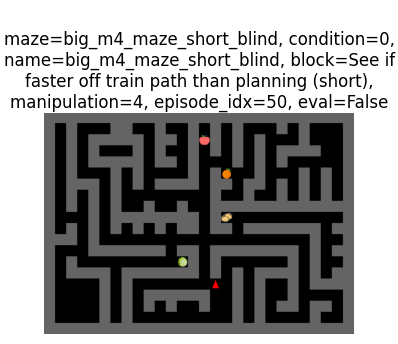

176
image: 2024-10-23T14:01:56.921Z
action time: 2024-10-23T14:01:57.425Z
action: 2


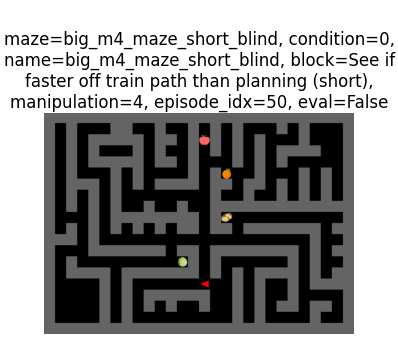

177
image: 2024-10-23T14:01:57.425Z
action time: 2024-10-23T14:01:57.994Z
action: 3


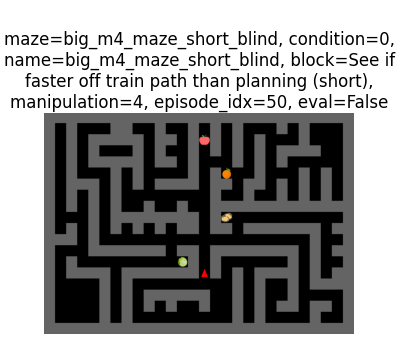

178
image: 2024-10-23T14:01:57.994Z
action time: 2024-10-23T14:01:58.493Z
action: 3


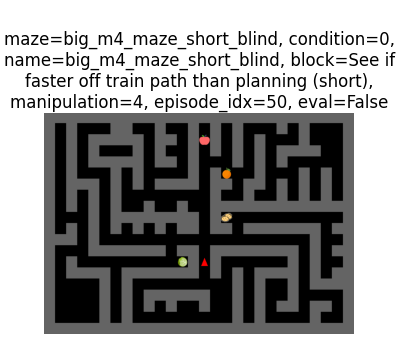

179
image: 2024-10-23T14:01:57.994Z
action time: 2024-10-23T14:01:58.523Z
action: 3


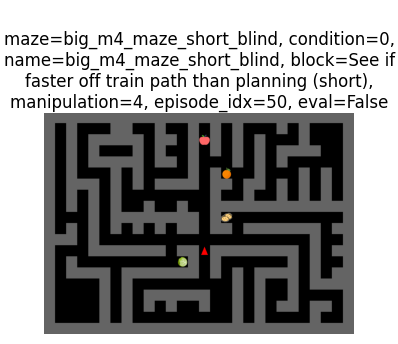

180
image: 2024-10-23T14:01:57.994Z
action time: 2024-10-23T14:01:58.556Z
action: 3


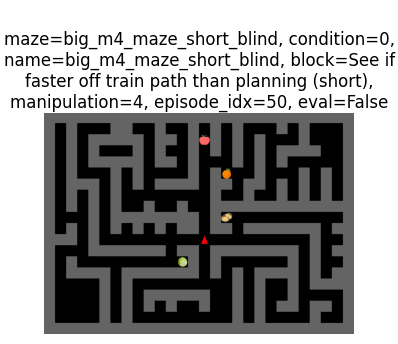

181
image: 2024-10-23T14:01:57.994Z
action time: 2024-10-23T14:01:58.583Z
action: 3


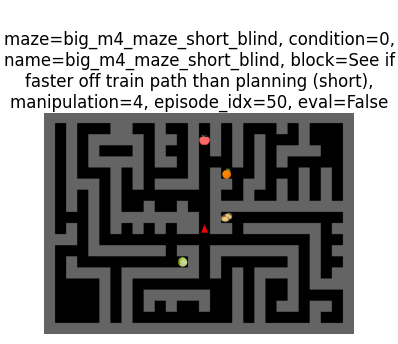

182
image: 2024-10-23T14:01:57.994Z
action time: 2024-10-23T14:01:58.624Z
action: 3


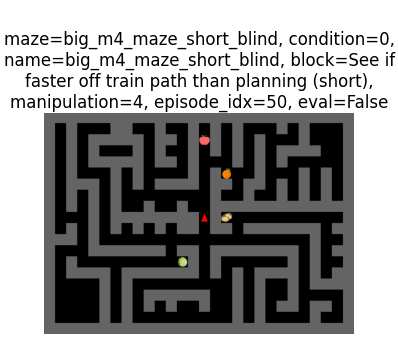

183
image: 2024-10-23T14:01:57.994Z
action time: 2024-10-23T14:01:58.660Z
action: 3


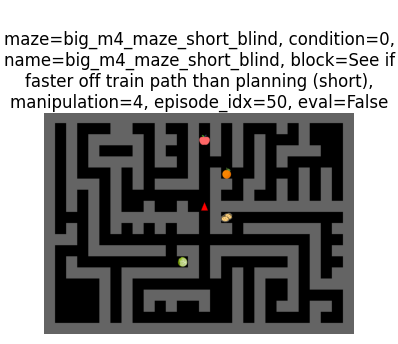

184
image: 2024-10-23T14:01:57.994Z
action time: 2024-10-23T14:01:58.685Z
action: 3


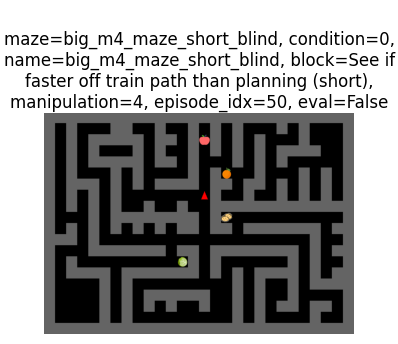

185
image: 2024-10-23T14:01:57.994Z
action time: 2024-10-23T14:01:58.724Z
action: 3


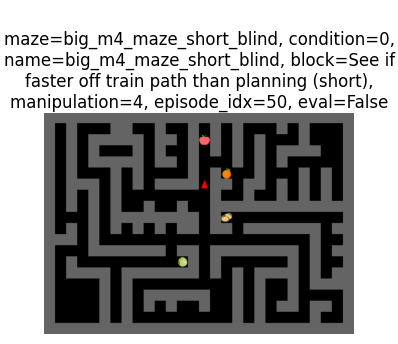

186
image: 2024-10-23T14:01:57.994Z
action time: 2024-10-23T14:01:58.754Z
action: 3


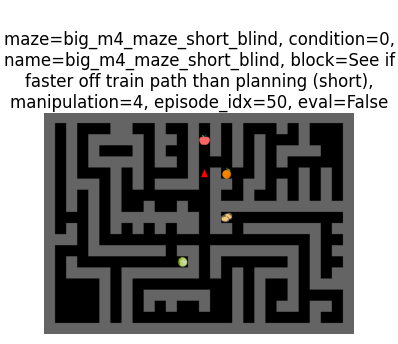

187
image: 2024-10-23T14:01:58.754Z
action time: 2024-10-23T14:01:58.783Z
action: 3


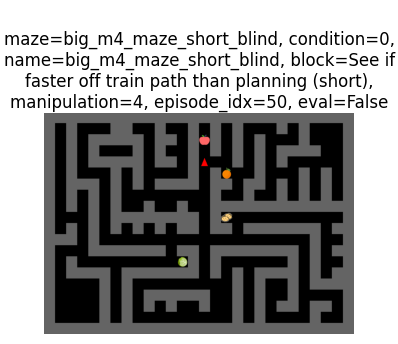

188
image: 2024-10-23T14:01:58.783Z
action time: 2024-10-23T14:01:58.823Z
action: 3


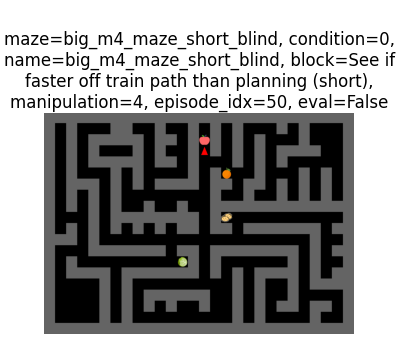

189
image: 2024-10-23T14:01:58.783Z
action time: 2024-10-23T14:01:58.854Z
action: 3


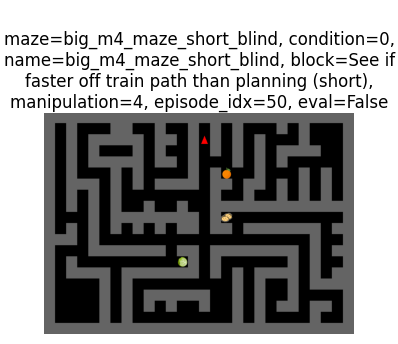

190
image: 2024-10-23T14:01:58.854Z
action time: 2024-10-23T14:01:58.884Z
action: 3


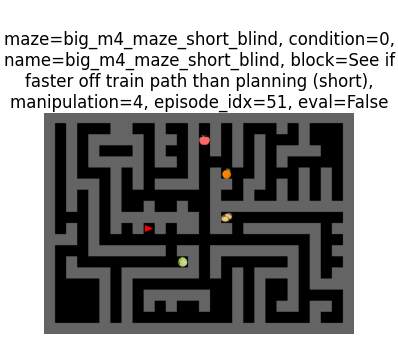

191
image: 2024-10-23T14:01:59.690Z
action time: 2024-10-23T14:01:59.690Z
action: -1


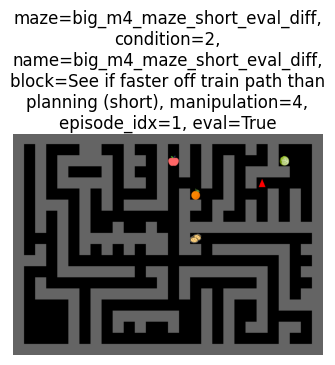

192
image: 2024-10-23T14:02:02.124Z
action time: 2024-10-23T14:02:04.576Z
action: 0


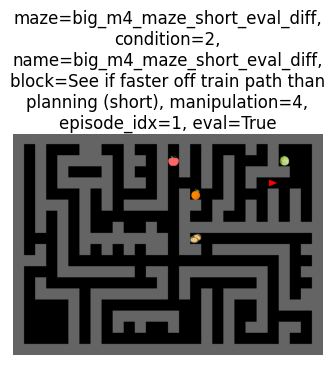

193
image: 2024-10-23T14:02:04.576Z
action time: 2024-10-23T14:02:05.024Z
action: 0


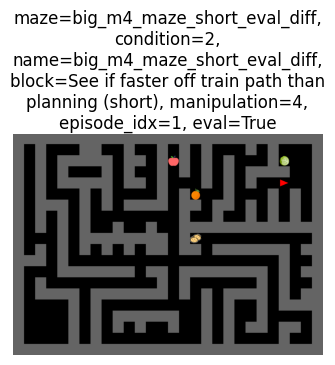

194
image: 2024-10-23T14:02:05.024Z
action time: 2024-10-23T14:02:05.256Z
action: 0


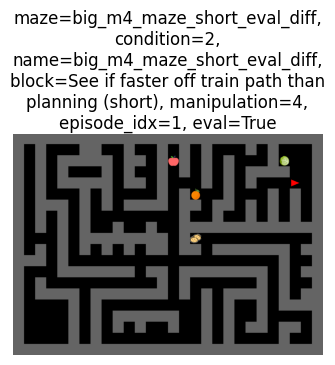

195
image: 2024-10-23T14:02:05.256Z
action time: 2024-10-23T14:02:05.927Z
action: 3


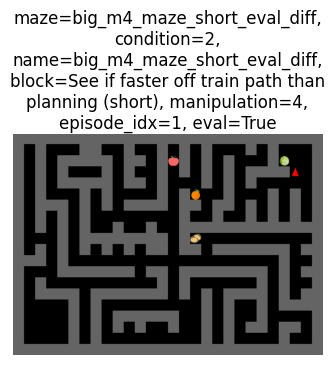

196
image: 2024-10-23T14:02:05.927Z
action time: 2024-10-23T14:02:06.192Z
action: 3


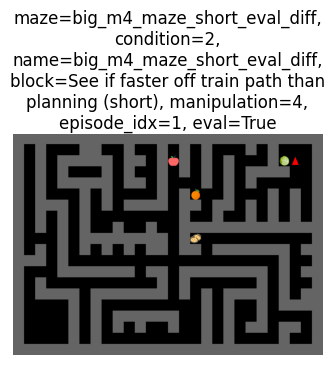

197
image: 2024-10-23T14:02:06.192Z
action time: 2024-10-23T14:02:06.192Z
action: -1


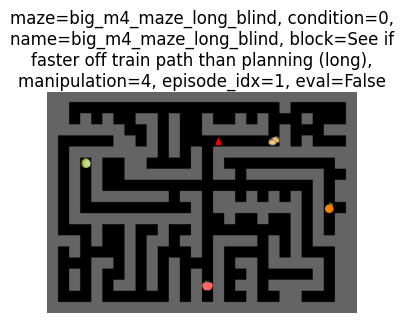

198
image: 2024-10-23T14:02:14.767Z
action time: 2024-10-23T14:02:17.103Z
action: 2


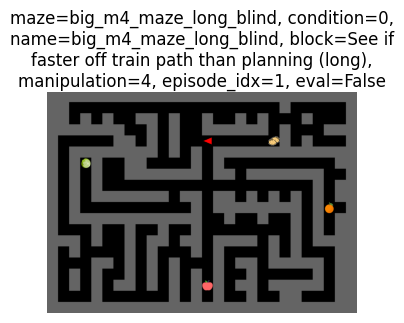

199
image: 2024-10-23T14:02:17.103Z
action time: 2024-10-23T14:02:17.655Z
action: 1


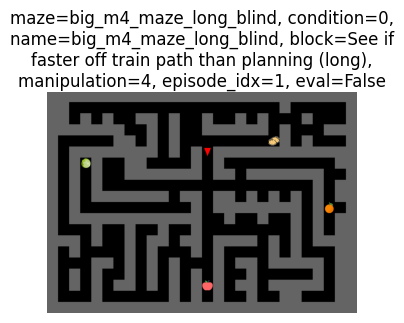

200
image: 2024-10-23T14:02:17.655Z
action time: 2024-10-23T14:02:18.159Z
action: 1


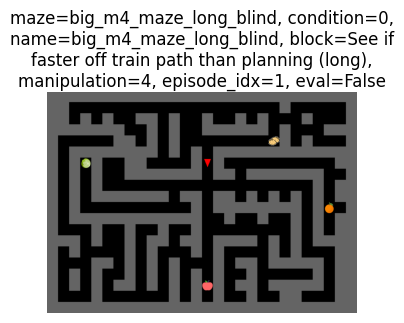

201
image: 2024-10-23T14:02:17.655Z
action time: 2024-10-23T14:02:18.190Z
action: 1


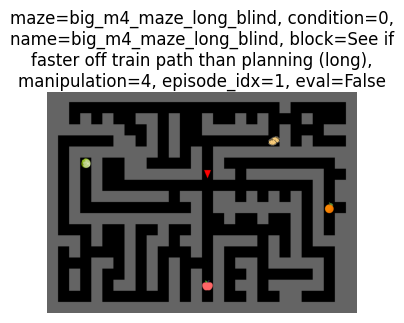

202
image: 2024-10-23T14:02:17.655Z
action time: 2024-10-23T14:02:18.221Z
action: 1


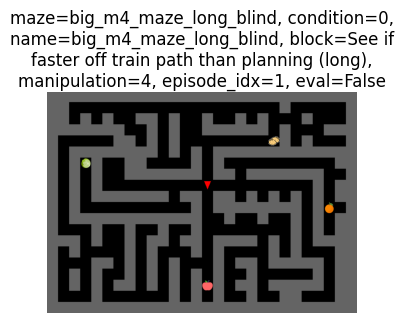

203
image: 2024-10-23T14:02:17.655Z
action time: 2024-10-23T14:02:18.250Z
action: 1


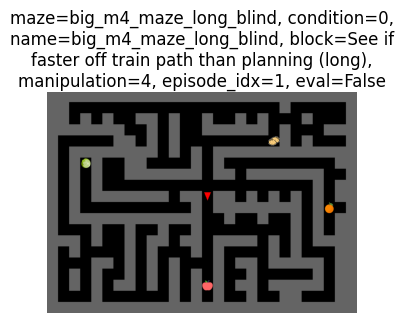

204
image: 2024-10-23T14:02:17.655Z
action time: 2024-10-23T14:02:18.290Z
action: 1


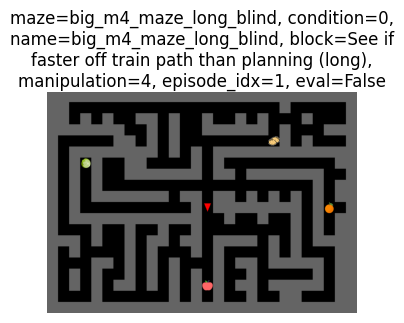

205
image: 2024-10-23T14:02:17.655Z
action time: 2024-10-23T14:02:18.319Z
action: 1


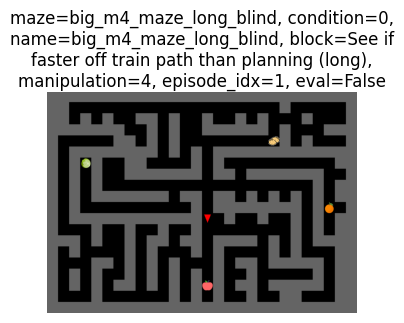

206
image: 2024-10-23T14:02:17.655Z
action time: 2024-10-23T14:02:18.348Z
action: 1


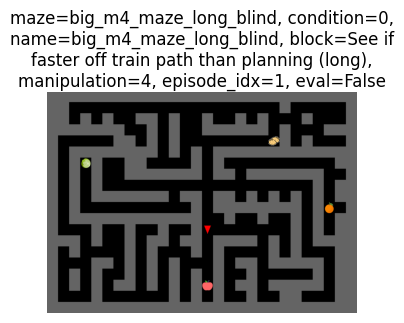

207
image: 2024-10-23T14:02:18.348Z
action time: 2024-10-23T14:02:18.388Z
action: 1


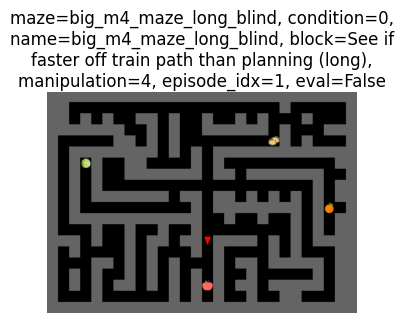

208
image: 2024-10-23T14:02:18.348Z
action time: 2024-10-23T14:02:18.420Z
action: 1


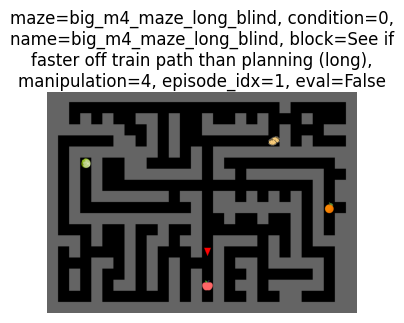

209
image: 2024-10-23T14:02:18.420Z
action time: 2024-10-23T14:02:18.448Z
action: 1


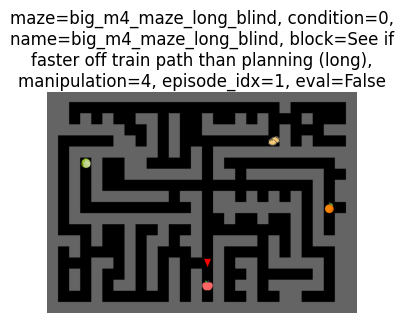

210
image: 2024-10-23T14:02:18.420Z
action time: 2024-10-23T14:02:18.488Z
action: 1


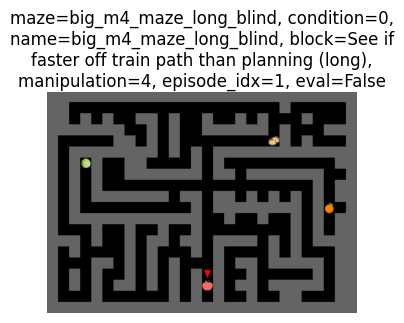

211
image: 2024-10-23T14:02:18.420Z
action time: 2024-10-23T14:02:18.518Z
action: 1


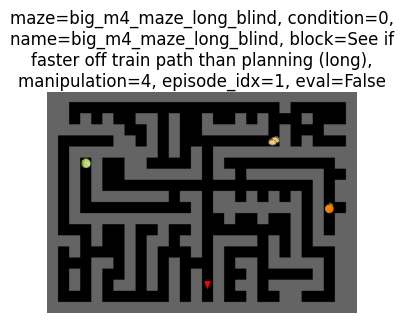

212
image: 2024-10-23T14:02:18.518Z
action time: 2024-10-23T14:02:18.549Z
action: 1


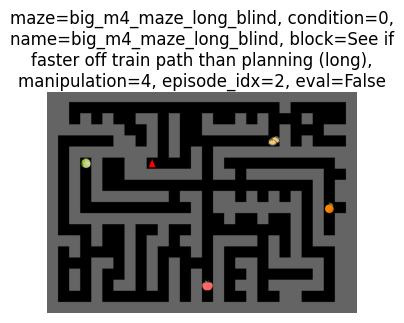

213
image: 2024-10-23T14:02:18.518Z
action time: 2024-10-23T14:02:18.580Z
action: 1


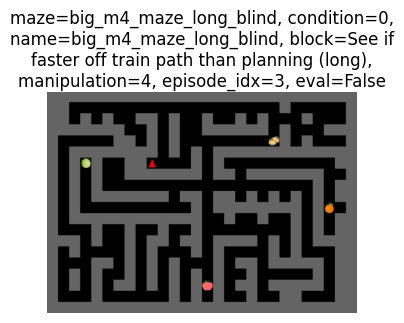

214
image: 2024-10-23T14:02:18.518Z
action time: 2024-10-23T14:02:18.619Z
action: 1


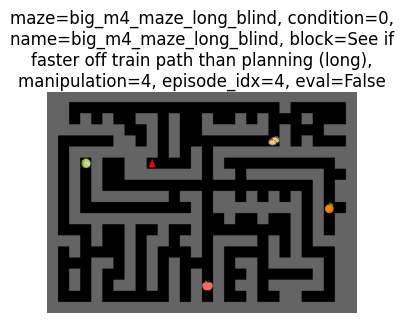

215
image: 2024-10-23T14:02:18.518Z
action time: 2024-10-23T14:02:18.649Z
action: 1


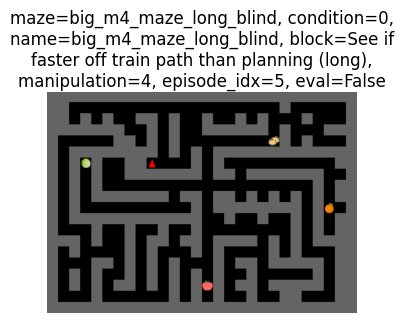

216
image: 2024-10-23T14:02:18.518Z
action time: 2024-10-23T14:02:18.679Z
action: 1


In [85]:
from analysis.data_loading import get_block_stage_description, dict_to_string, get_timestep
from analysis.housemaze import housemaze_render_fn
import matplotlib.pyplot as plt

# let's just print out the first few time-step to see what they look like
keys = set()
# nidx = 2
nidx = len(data_dicts)
for idx in range(nidx):
    datum = data_dicts[idx]
    if 'finished' in datum.keys(): continue
    # get the information describing block x stage pairs. you can edit this function if you want
    info = get_block_stage_description(datum)
    title = dict_to_string(info)
    if idx < 100: continue
    if not title in keys:
        print("="*100)
        keys.add(title)
    
    timestep = get_timestep(datum, example_web_timestep)
    image = housemaze_render_fn(timestep.state)
    # action_taken: int = datum['action_idx']

    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(title, wrap=True)
    plt.show()

    print(idx)
    print('image:', datum['data']['image_seen_time'])
    print('action time:', datum['data']['action_taken_time'])
    print('action:', datum['data']['action_idx'])
    if datum['metadata']['episode_idx'] == 5:
        break
    

In [27]:
datum

{'id': 5320,
 'session_id': 'd480bbca-3c1e-4d63-ab2d-05e1e80582fd',
 'name': 'big_m4_maze_short',
 'stage_idx': 20,
 'data': {'image_seen_time': '2024-10-20T03:20:14.096Z',
  'action_taken_time': '2024-10-20T03:20:14.332Z',
  'computer_interaction': 'ArrowUp',
  'action_name': 'up',
  'action_idx': 3,
  'timelimit': None,
  'timestep': 'hqVzdGF0ZY2ja2V5gqEwzjkdQCqhMc5A4wxfqHN0ZXBfbnVtAKRncmlk3gASoTDeABqhMIGhMAChMYGhMAChMoGhMAChM4GhMAGhNIGhMAChNYGhMAGhNoGhMAChN4GhMAChOIGhMAChOYGhMAGiMTCBoTAAojExgaEwAaIxMoGhMACiMTOBoTABojE0gaEwAKIxNYGhMACiMTaBoTABojE3gaEwAKIxOIGhMACiMTmBoTABojIwgaEwAaIyMYGhMACiMjKBoTAAojIzgaEwAKIyNIGhMAGiMjWBoTAAoTHeABqhMIGhMAChMYGhMAChMoGhMAChM4GhMAGhNIGhMAChNYGhMAChNoGhMAChN4GhMAGhOIGhMAChOYGhMAGiMTCBoTAfojExgaEwAaIxMoGhMA2iMTOBoTABojE0gaEwAKIxNYGhMAGiMTaBoTABojE3gaEwAKIxOIGhMAGiMTmBoTABojIwgaEwAaIyMYGhMAGiMjKBoTABojIzgaEwAKIyNIGhMAGiMjWBoTAAoTLeABqhMIGhMAChMYGhMAChMoGhMAGhM4GhMAGhNIGhMAGhNYGhMAGhNoGhMAChN4GhMAGhOIGhMAChOYGhMAGiMTCBoTAAojExgaEwAaIxMoGhMACiMTOBoTABojE0g

In [29]:
data_dicts[idx-1]

{'id': 5319,
 'session_id': 'd480bbca-3c1e-4d63-ab2d-05e1e80582fd',
 'name': 'big_m4_maze_short',
 'stage_idx': 20,
 'data': {'image_seen_time': '2024-10-20T03:20:14.096Z',
  'action_taken_time': '2024-10-20T03:20:14.300Z',
  'computer_interaction': 'ArrowUp',
  'action_name': 'up',
  'action_idx': 3,
  'timelimit': None,
  'timestep': 'hqVzdGF0ZY2ja2V5gqEwzjkdQCqhMc5A4wxfqHN0ZXBfbnVtAKRncmlk3gASoTDeABqhMIGhMAChMYGhMAChMoGhMAChM4GhMAGhNIGhMAChNYGhMAGhNoGhMAChN4GhMAChOIGhMAChOYGhMAGiMTCBoTAAojExgaEwAaIxMoGhMACiMTOBoTABojE0gaEwAKIxNYGhMACiMTaBoTABojE3gaEwAKIxOIGhMACiMTmBoTABojIwgaEwAaIyMYGhMACiMjKBoTAAojIzgaEwAKIyNIGhMAGiMjWBoTAAoTHeABqhMIGhMAChMYGhMAChMoGhMAChM4GhMAGhNIGhMAChNYGhMAChNoGhMAChN4GhMAGhOIGhMAChOYGhMAGiMTCBoTAfojExgaEwAaIxMoGhMA2iMTOBoTABojE0gaEwAKIxNYGhMAGiMTaBoTABojE3gaEwAKIxOIGhMAGiMTmBoTABojIwgaEwAaIyMYGhMAGiMjKBoTABojIzgaEwAKIyNIGhMAGiMjWBoTAAoTLeABqhMIGhMAChMYGhMAChMoGhMAGhM4GhMAGhNIGhMAGhNYGhMAGhNoGhMAChN4GhMAGhOIGhMAChOYGhMAGiMTCBoTAAojExgaEwAaIxMoGhMACiMTOBoTABojE0g